In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Convert a number to hex and return a list of digit tokens
def number_to_hex_digits(num):
    hex_str = hex(num)[2:].upper()  # Convert to hex (remove '0x' and make uppercase)
    return [int(char, 16) for char in hex_str]  # Convert hex characters to indices

# Generate dataset: multiple numbers → hex → sorted hex list
def generate_data(num_samples=1000, max_num=999):
    data = []
    for _ in range(num_samples):
        numbers = [random.randint(0, max_num) for _ in range(random.randint(1, 5))]  # Random list of 1-5 numbers
        hex_digits = [digit for num in numbers for digit in number_to_hex_digits(num)]  # Flatten hex digits
        sorted_hex_digits = sorted(hex_digits)  # Sorting step
        data.append((hex_digits, sorted_hex_digits))
    return data

# Token and Positional Embedding
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

    def forward(self, x):
        return self.embedding(x)

class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=20):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)

# Transformer Encoder Layer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, hidden_dim):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)
        ffn_output = self.ffn(x)
        return self.norm2(x + ffn_output)

# Transformer Encoder Model
class TransformerSorter(nn.Module):
    def __init__(self, vocab_size=16, embed_dim=64, num_heads=4, hidden_dim=128, num_layers=4):
        super().__init__()
        self.token_embed = TokenEmbedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)
        self.encoder_layers = nn.Sequential(*[TransformerEncoderLayer(embed_dim, num_heads, hidden_dim) for _ in range(num_layers)])
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.token_embed(x)
        x = self.positional_encoding(x)
        x = self.encoder_layers(x)
        return self.output_layer(x)

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001

# Model, Loss, Optimizer
model = TransformerSorter().to(device)  # Move model to GPU if available
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

# Generate Training Data
dataset = generate_data()
train_data = [(torch.tensor(x, device=device), torch.tensor(y, device=device)) for x, y in dataset]

scaler = torch.amp.GradScaler()

for epoch in range(EPOCHS):
    total_loss = 0
    for x, y in train_data:
        x, y = x.unsqueeze(0), y.unsqueeze(0)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            output = model(x)
            loss = criterion(output.view(-1, 16), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_data):.4f}")
    
# Test Prediction Function
def predict_sorting(model, numbers):
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            hex_seq = [digit for num in numbers for digit in number_to_hex_digits(num)]
            x = torch.tensor(hex_seq, device=device).unsqueeze(0)  # Add batch dim
            output = model(x)
            predicted = torch.argmax(output, dim=-1).squeeze(0)
            predicted_hex = [format(p.item(), 'X') for p in predicted]
            return predicted_hex



Training on: cpu


C:\Users\Justin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


Epoch 1, Loss: 2.1160
Epoch 2, Loss: 1.3686
Epoch 3, Loss: 0.9728
Epoch 4, Loss: 0.7143
Epoch 5, Loss: 0.5470
Epoch 6, Loss: 0.4299
Epoch 7, Loss: 0.3424
Epoch 8, Loss: 0.2689
Epoch 9, Loss: 0.2157
Epoch 10, Loss: 0.1782
Epoch 11, Loss: 0.1588
Epoch 12, Loss: 0.1345
Epoch 13, Loss: 0.1209
Epoch 14, Loss: 0.0898
Epoch 15, Loss: 0.0681
Epoch 16, Loss: 0.0727
Epoch 17, Loss: 0.0827
Epoch 18, Loss: 0.0624
Epoch 19, Loss: 0.0706
Epoch 20, Loss: 0.0420
Epoch 21, Loss: 0.0324
Epoch 22, Loss: 0.0857
Epoch 23, Loss: 0.0364
Epoch 24, Loss: 0.0495
Epoch 25, Loss: 0.0181
Epoch 26, Loss: 0.0316
Epoch 27, Loss: 0.0800
Epoch 28, Loss: 0.0205
Epoch 29, Loss: 0.0105
Epoch 30, Loss: 0.0079
Epoch 31, Loss: 0.0474
Epoch 32, Loss: 0.0690
Epoch 33, Loss: 0.0141
Epoch 34, Loss: 0.0081
Epoch 35, Loss: 0.0050
Epoch 36, Loss: 0.0038
Epoch 37, Loss: 0.0915
Epoch 38, Loss: 0.0273
Epoch 39, Loss: 0.0078
Epoch 40, Loss: 0.0038
Epoch 41, Loss: 0.0029
Epoch 42, Loss: 0.0024
Epoch 43, Loss: 0.0019
Epoch 44, Loss: 0.12

In [3]:
numbers = [25, 8, 250]  # Example list of numbers
sorted_hex = predict_sorting(model, numbers)
print(f"Original Numbers: {numbers} → Sorted Hex Digits: {sorted_hex}")

Original Numbers: [25, 8, 250] → Sorted Hex Digits: ['1', '8', '9', 'A', 'F']


In [4]:
torch.save(model, 'full_model.pth')

In [5]:
# Save the model's state_dict instead of the full model
torch.save(model.state_dict(), 'model_state_dict.pth')


Average accuracy: 77.3%
Average leaks per data point: 38.6
Average leakage: 3.8600000000000003%
Average correct = 773.0
Average incorrect = 227.0 
Total = 1000.0



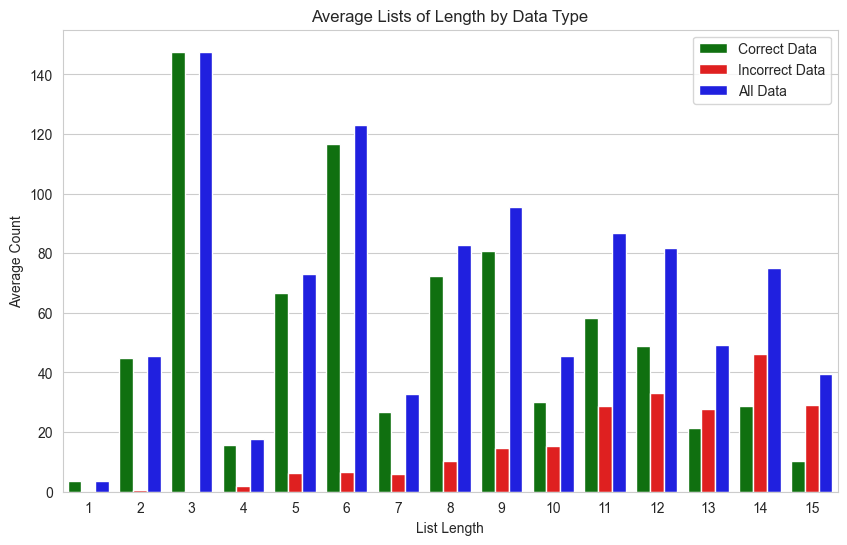

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


iterations = 10
test_size = 1000
incorrect = [0]*iterations
leak = [0]*iterations

incorrect_data = []
correct_data = []
all_data = []

for i in range(0, iterations):
    test_data = generate_data(test_size)
    for j in range(0, 1000):
        numbers = test_data[j][0]
        sorted_hex = predict_sorting(model, numbers)
        sorted_hex = [int(num, 16) for num in sorted_hex]
        if test_data[j][1] != sorted_hex:
            incorrect[i] += 1
            incorrect_data.append(test_data[j])
        else:
            correct_data.append(test_data[j])
        all_data.append(test_data[j])

    for test_sample in dataset:
        if test_sample in test_data:
            leak[i] += 1

# Print results
print(f"Average accuracy: {100 - (sum(incorrect) / (1000 * iterations)) * 100}%")
print(f"Average leaks per data point: {sum(leak) / iterations}")
print(f"Average leakage: {sum(leak) / (test_size * iterations) * 100}%")

# Calculate average counts for each list length
def calculate_average_counts(dataset, max_length):
    counts = [0] * max_length
    for data in dataset:
        length = len(data[0])
        counts[length - 1] += 1  # Adjust index for 0-based indexing
    return [count / iterations for count in counts]  # Divide by iterations for average

# Determine the maximum list length
max_length = max(len(data[0]) for data in all_data)

# Calculate average counts for each dataset
correct_data_avg = calculate_average_counts(correct_data, max_length)
incorrect_data_avg = calculate_average_counts(incorrect_data, max_length)
all_data_avg = calculate_average_counts(all_data, max_length)
print(
f"""Average correct = {sum(correct_data_avg)}
Average incorrect = {sum(incorrect_data_avg)} 
Total = {sum(all_data_avg)}
""")

lengths = np.arange(1, max_length + 1)

data = {
    'List Length': np.tile(lengths, 3),
    'Average Count': correct_data_avg + incorrect_data_avg + all_data_avg,
    'Data Type': ['Correct Data'] * max_length + ['Incorrect Data'] * max_length + ['All Data'] * max_length
}

df = pd.DataFrame(data)

# Set style
sns.set_style("whitegrid")

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='List Length', y='Average Count', hue='Data Type', data=df, palette=['g', 'r', 'b'])

# Labels and title
plt.xlabel('List Length')
plt.ylabel('Average Count')
plt.title('Average Lists of Length by Data Type')
plt.legend()

# Show plot
plt.show()

## Model Performance

With the above statistics, we see that our average accuracy is usually just over 75%, not bad but it definately could be improved. Upon further investigation, we find that around 4% of the data in our testing dataset is also present in our training dataset. Additionally, there are very few occurrences of lists with lengths 1, 4, and 7. This is due to how our `generate_data` function converts decimal values to hexadecimal.

Note: this 4% is for test_size = 1000, he higher the test size the lower this percentage.

### `generate_data()` Pseudo Code:
- The function picks a random integer between 1 and 5 (inclusive), which determines the length of the decimal list.
- It then selects a new integer between 0 and 999 (inclusive) and places that integer into a position in the list and does that for each position in the list.
- Each decimal value is then converted to hexadecimal and "flattened." For example, `[200] → [C8] → [C, 8]`.

There are only 16 cases where a list of length 1 is created. This happens when the list length is 1 and the hex value falls between 0 and 15. That is why we see very few observations of length 1.

Now, let's analyze the case when a list of length 1 is generated. Since the decimal value is limited to the range 0–999, it is impossible to generate a hexadecimal representation of length 4 or 7. In fact, there are only three cases:

- If the generated number is between 0 and $ (16^1)-1 $, the list will be of length 1:

  $$
  p_1 = \frac{16 \text{ observations of length 1}}{1000 \text{ total observations}} = 1.6\%
  $$

- If the generated number is between $ 16^1 $ and $ (16^2)-1 $, the list will be of length 2:

  $$
  p_2 = \frac{240 \text{ observations of length 2}}{1000 \text{ total observations}} = 24\%
  $$

- If the generated number is between $ 16^2 $ and 999, the list will be of length 3:

  $$
  p_3 = \frac{744 \text{ observations of length 3}}{1000 \text{ total observations}} = 74.4\%
  $$

Since the function randomly selects the initial list length between 1 and 5, 20% of the time (1/5), we will only get list lengths between 1 and 3. Additionally, because the function picks a random number for the list length, almost 75% of the time, this list will be of length 3. This explains why we observe more lists of length 3 than any other length. While this same analysis can be applied to cases where the initial length is greater than 1, it quickly becomes more complex, though the overall trend remains similar.

Despite the data being skewed, the model tends to predict lists of length 4 and 7 more often than expected. As list size increases, the number of possible combinations grows. With more combinations, the model struggles to find patterns in the data, leading to lower accuracy. This explains why accuracy worsens as list size increases, even though there is more training data available for larger list sizes compared to lengths 4 and 7.

To summerize, our model does not preform well because:
- ~4% of the data from the training set is present in the testing set.
- The data that the model was trained on is skewed.
- The model preforms better when it has more data and when the list length is shorter.